# Week 3: Iterační metody pro řešení lineárních algebraických systémů

**Assignment:** [![Run in JupyterHub](https://img.shields.io/badge/Run%20in-JupyterHub-F37626?logo=jupyter)](https://hpc.troja.mff.cuni.cz:8000/hub/user-redirect/git-pull?app=lab&repo=https%3A%2F%2Fgitlab.karlin.mff.cuni.cz%2Fznm%2Fcviceni-student&branch=main&subpath=notebooks%2Fassignment%2Fweek-03-iterative-methods.ipynb) [![Download .ipynb](https://img.shields.io/badge/Download-.ipynb-blue)](https://gitlab.karlin.mff.cuni.cz/znm/cviceni-student/-/raw/main/notebooks/assignment/week-03-iterative-methods.ipynb?inline=false) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/num-math/cviceni-student/blob/main/notebooks/assignment/week-03-iterative-methods.ipynb)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

---
- [poznámky z přednášky](https://www.karlin.mff.cuni.cz/~blechta/znm/assets/Reseni_soustav.pdf)
- další materiály
  - kniha [Duintjer Tebbens a kolektiv: Analýza metod pro maticové výpočty](https://cuni.primo.exlibrisgroup.com/discovery/fulldisplay?docid=alma990020832750106986&context=L&vid=420CKIS_INST:UKAZ&lang=cs&search_scope=MyInst_and_CI&adaptor=Local%20Search%20Engine&tab=Everything&query=any,contains,Anal%C3%BDza%20metod%20pro%20maticov%C3%A9%20v%C3%BDpo%C4%8Dty&offset=0)  (Sekce 9.1)
  - kniha [Y. Saad: Iterative Methods for Sparse Linear Systems](https://www-users.cse.umn.edu/~saad/IterMethBook_2ndEd.pdf) (Kapitola 4; bible oboru)
  - skripta [Foundations of Applied Mathematics](https://foundations-of-applied-mathematics.github.io/) (Volume 1, Kapitola 15)

- ***Primární úlohy*** : A1, A2, B1

- ***Úlohy k bonusové části zkoušky*** : A1, A2

- základní ***Learning outcomes*** (cviko, nikoliv přednáška)
  - Umím pro dané štěpení matice $A$ odvodit podmínky na konvergenci odpovídající stacionární metody.
  - Z grafů v lineárním, semilogaritmickém i logaritmickém (na obou osách) měřítku určím asymptotický řád konvergence.
  - Umím vysvětlit rozdíl v konvergenci stacionárních metod pro případ, kdy je iterační matice symetrická a kdy diagonalizovatelná, ale nikoliv pomocí unitární transformace.
  - Pro danou stacionární metodu dokážu odvodit její formulaci jako polynomiální metody.

---

## Intro

První, klasický způsob řešení

$$ A\mathbf{x} = \mathbf{b} \qquad (\star) $$

jsme už částečně potkali v minulém cviku - Gaussova eliminace s částečnou pivotací (nebo ekvivalentně LU rozklad a odpovídající problémy s trojúhelníkovými maticemi). Dvě hlavní nevýhody jsou

> Nemůžeme jednoduše ovlivnit přesnost řešení:
  - v mnoha (téměř ve většině) aplikacích máme data z reálného měření/simulací, které jsou sami o sobě zatéžené nějakou chybou - většinou výrazně vyšší než $\varepsilon_{mach}$. Pokud víme, že $A$ a $\mathbf{b}$ jsou zatíženy chybou řádu $\delta \gg \varepsilon_{mach}$, dává smysl se ptát na řešení splňující $(\star)$ pouze na úrovni $\delta$ - například můžeme hledat $\mathbf{x}_{\delta}$ takové, že platí pouze
  $$ \| \underbrace{ \mathbf{b} - A \mathbf{x}_{\delta} }_{=: \, \mathbf{r}_{\delta} \, \leftarrow \, \mathrm{ tzv. \; reziduum}} \| \approx \delta. $$
  Gaussova eliminace nám nic takového sama o sobě neumožňuje a tedy musíme "ztrácet čas" výpočtem $\mathbf{x}$ v přesnosti $\varepsilon_{mach}$. Jednou možností jak umožnit "kontrolu přesnosti řešení" v průběhu výpočtu jsou iterační metody.
  - alternativní formulace téhle nevýhody je, že nejsme schopni kontrolovat čas výpočtu. Pokud víme, že máme na výpočet pouze několik vteřin/minut, protože pak už je výsledek bezcenný (např. předpověď počasí, trading na burzách, ...) a náš odhad časové náročnosti Gaussovy eliminace
  $$\# \,\mathrm{flops} \sim \frac{2}{3}n^3 + \mathcal{O}(n^2)$$
  predikuje, že řešení $(\star)$ bude trvat déle, pak zjevně potřebujeme jiný postup. Jednou možností jsou iterační metody.

> Nemáme safety-points:
  - podle věty o stabilitě LU rozkladu s částečnou pivotací (a tedy Gaussovy eliminace) můžeme stabilitu výpočtu monitorovat v průběhu samotného výpočtu - stačí kontrolovat velikosti prvků v již spočtených částech matic $L$ a $U$ (v porovnání s velikostmi prvků $A$). Ovšem v minulém cvičení jsme viděli, že na problém můžeme narazit až u konce tohoto procesu - pro Wilkinsonovy matice $W_n$ nám stabilita exponenciálně klesala s počtem kroků, které už jsme v procesu LU-rozkladu udělali.
  - Může se tedy stát, že po hodinách a hodinách výpočtu stabilitu "úplně ztratíme" (tj. až po těch hodinách výpočtu uvidíme, že námi vypočtený LU-rozklad není dostatečně stabilní) a musíme začít opět úplně od začátku. Nemáme žádné "přibližné řešení", nic čím bychom mohli ty hodiny výpočtu "obhájit". Přirozenou možností jak toto napravit jsou iterační metody.


Přímé metody pro řešení $(\star)$ (jako například LU rozklad, ale uvidíme v průběhu první půlky semestru i další), po nějaké době výpočtu, vydají jedno numerické řešení. Myšlenka iteračních metod je principálně odlišná, spočívá v konstrukci *posloupnosti aproximací* (přibližných řešení) $\mathbf{x}_0, \mathbf{x}_1, \mathbf{x}_2, \ldots $, která by se měla přibližovat skutečnému řešení $\mathbf{x}$.

## Část A: Klasické iterační metody (aka [stacionární](https://en.wikipedia.org/wiki/Iterative_method#Stationary_iterative_methods))

### Shrnutí látky z přednášky & značení

Klasické iterační metody jsou založeny na štěpení matice soustavy $A = M-N$, kde matice $M$ je regulární a umíme efektivně řešit problémy typu $M\mathbf{x} = \mathbf{b}$.

Dosazením do vztahu $A\mathbf{x}=\mathbf{b}$ postupně dostáváme

$$ (M-N)\mathbf{x} = \mathbf{b} $$
$$ M\mathbf{x} = N\mathbf{x} + \mathbf{b} $$
$$ \mathbf{x} = M^{-1}N\mathbf{x} + M^{-1}\mathbf{b}. $$

Máme-li počáteční aproximaci řešení $\mathbf{x}_0$, pak můžeme nastartovat iterační proces
$$ \mathbf{x}_k = M^{-1}N \mathbf{x}_{k-1} + M^{-1}\mathbf{b}. $$

Klasické iterační metody jsou založeny na štěpení ve tvaru

$$
A =
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\underbrace{ \begin{bmatrix}
a_{1,1} & 0 & \cdots & 0 \\
0 & \ddots & \ddots & \vdots \\
\vdots & \ddots & \ddots & 0 \\
0 & \cdots & 0 & a_{n,n} \\
\end{bmatrix} }_{=: \, D} -
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\underbrace{ \begin{bmatrix}
0 & 0 & \cdots & 0 \\
-a_{2,1} & \ddots & \ddots & \vdots \\
\vdots & \ddots & \ddots & 0 \\
-a_{n,1} & \cdots & -a_{n,n-1} & 0 \\
\end{bmatrix} }_{=: \, L} -
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\underbrace{ \begin{bmatrix}
0 & -a_{1,2} & \cdots & -a_{1,n} \\
0 & \ddots & \ddots & \vdots \\
\vdots & \ddots & \ddots & -a_{n-1,n} \\
0 & \cdots & 0 & 0 \\
\end{bmatrix} }_{=: \, U}$$

kde $D$ je hlavní diagonála, $-L$ je striktně dolní trojúhelník matice $A$ a $-U$ je striktně horní trojúhelník matice $A$.

- V [Jacobiho metodě](https://en.wikipedia.org/wiki/Jacobi_method) volíme $M=D$, $N = L+U$, a je tedy definována iterací
$$D \mathbf{x}_{k} = (L + U)\mathbf{x}_{k-1} +\mathbf{b},$$

- [Gaussova-Seidelova metoda](https://en.wikipedia.org/wiki/Gauss%E2%80%93Seidel_method) používá $M=D-L$, $N = U$ a je definována jako
$$ (D-L) \mathbf{x}_{k} = U \mathbf{x}_{k-1} +\mathbf{b}.$$


- Další metodou, která je (po jistých adaptacích) užitečná je [Richardsonova metoda](https://en.wikipedia.org/wiki/Modified_Richardson_iteration), která odpovídá volbě $M=I$, $N = I-A$, a je tedy definována iterací
$$ \mathbf{x}_{k} = (I-A)\mathbf{x}_{k-1} +\mathbf{b} = \mathbf{x}_{k-1} + (\mathbf{b} - A\mathbf{x}_{k-1}).$$




Pro analýzu klasických iteračních metod je důležitý vztah mezi chybami dvou následujících přibližných řešení, tj. mezi $\mathbf{e}_{k} :=\mathbf{x} - \mathbf{x}_{k}$ a $\mathbf{e}_{k-1} := \mathbf{x}_{k} - \mathbf{x}_{k-1}$:

$$
\mathbf{e}_{k} = M^{-1}N \mathbf{e}_{k-1} = (I - M^{-1}A) \mathbf{e}_{k-1}  = \cdots = (I - M^{-1}A)^k \mathbf{e}_{0},
$$

který jsme viděli na přednášce. Říká nám, že pokud chceme aby chyba $\mathbf{e}_{k} = \mathbf{x} - \mathbf{x}_{k}$ konvergovala k $\mathbf{0}$ pro libovolné $\mathbf{e}_{0}$, pak nutně musí platit

$$ (I - M^{-1}A)^k \longrightarrow 0 \qquad \mathrm{pro} \; k\rightarrow +\infty. $$

Opět z přednášky víme, že

$$ (I - M^{-1}A)^k \longrightarrow 0 \quad \mathrm{pro} \; k\rightarrow +\infty  \quad \iff \quad \underbrace{ \left( \max\limits_{\lambda \, \mathrm{je \, vl. \, cislo \,} I - M^{-1}A }  \, |\lambda| \right) }_{=: \, \rho(I - M^{-1}A) }  \; < 1. \qquad (\star \star)$$

### Úloha A1 - implementace

---
**Kódění**: Naimplementujte funkce `JacobihoMetoda()` a `GaussSeidelMetoda()` podle anotací níže.

- [Nápověda & hinty](#hinty-a1)

---

In [ ]:
def JacobihoMetoda(A,b,x0, nmb_iter):
  '''
  Implementace Jacobiho metody pro reseni "Ax=b" (*), ktera provede "nmb_iter" iteraci s pocatecnim odhadem "x0".

  Input
  -------
  A :  np.array dimenze "n-krat-n"s prvky np.float64. matice soustavy (*). Predpokladame, A je regularni a ze diagonalni prvky jsou nenulove.
  b :  np.array dimenze "n" s prvky np.float64. prava strana soustavy (*)
  x0 :  np.array dimenze "n" s prvky np.float64. pocatecni odhad na reseni soustavy (*)
  nmb_iter :  np.int32. Pocet iteraci algoritmu, nmb_iter > 0

  Output
  -------
  MojeAproximace : np.array dimenze "(nmb_iter+1)-krat-n". Musi platit "AproximaceKorene[i,:] = xi", kde "xi" je i-ta aproximace (tj. na vystupu vracime celou posloupnost aproximaci, vcetne te nulte)
  '''
  MojeAproximace = np.zeros(( ... , ... ))
  MojeAproximace[0,:] = ...

  M = ...
  N = ...

  for k in range(nmb_iter):
    MojeAproximace[k+1,:] = ...

  return MojeAproximace

In [ ]:
####################################################################
def test_JacobihoMetoda():
  x0 = np.array([0,0,0,0]); nmb_iter = 3

  A1 = np.array([ [4,0,0,0] , [0,3,0,0] , [0,0,2,0] , [0,0,0,1] ])
  b1 = np.array([1,1,1,1])
  MojeAproximace1 = JacobihoMetoda(A1,b1,x0, nmb_iter)
  ######################################
  assert MojeAproximace1.shape == (4,4), "Output 'JacobihoMetoda()' pro matici 4-krat-4 a 'nmb_iter = 3' by mel mit rozmery 4-krat-4, ale ma output rozmeru {}".format(MojeAproximace1.shape)
  assert np.linalg.norm(MojeAproximace1[0,:] - x0) < 1e-10, "Podle anotace funkce 'JacobihoMetoda()' by melo platit 'MojeAproximace1[:,0] - x0', ale kod nam vraci \n MojeAproximace1[:,0] = {}  a  x0 = {}".format(MojeAproximace1[:,0], x0)
  assert np.linalg.norm(A1 @ MojeAproximace1[1,:] - b1) < 1e-10, "Pro 'A' diagonalni by mela Jacobiho metoda zkonvergovat v prvni iteraci, ale to se nedeje"

  A2 = np.array([ [3,-1,0,0] , [-1,3,-1,0] , [0,-1,3,-1] , [0,0,-1,3] ])
  b2 = np.array([1,1,1,1])
  MojeAproximace2 = JacobihoMetoda(A2,b2,x0, nmb_iter)
  ######################################
  x1 = np.linalg.solve( np.diag( np.diag(A2) ), b2 )
  assert np.linalg.norm(MojeAproximace2[1,:] - x1) < 1e-10, "Pro 'x0 = 0' by mela Jacobiho metoda v prvni iteraci dat 'x1 = D^{-1} x0', ale to se nedeje"
  x2 = np.linalg.solve( np.diag(np.diag(A2)), (np.diag(np.diag(A2))-A2) @ x1 + b2 )
  assert np.linalg.norm(MojeAproximace2[2,:] - x2) < 1e-10, "Jacobiho metoda nepocita spravne - porad se se cvicicim"

  return "funkce 'JacobihoMetoda()' je OK"
test_JacobihoMetoda()

In [ ]:
def GaussSeidelMetoda(A,b,x0, nmb_iter):
  '''
  Implementace metody Gauss-Seidel pro reseni "Ax=b", ktera provede "nmb_iter" iteraci s  pocatecnim odhadem "x0".

  Input
  -------
  A :  np.array dimenze "n-krat-n"s prvky np.float64. matice soustavy (*). Predpokladame, A je regularni a ze diagonalni prvky jsou nenulove.
  b :  np.array dimenze "n" s prvky np.float64. prava strana soustavy (*)
  x0 :  np.array dimenze "n" s prvky np.float64. pocatecni odhad na reseni soustavy (*)
  nmb_iter :  np.int32. Pocet iteraci algoritmu, nmb_iter > 0

  Output
  -------
  MojeAproximace : np.array dimenze "(nmb_iter+1)-krat-n". Musi platit "AproximaceKorene[i,:] = xi", kde "xi" je i-ta aproximace (tj. na vystupu vracime celou posloupnost aproximaci, vcetne te nulte)
  '''
  MojeAproximace = np.zeros(( ... , ... ))
  MojeAproximace[0,:] = ...

  M = ...
  N = ...

  for k in range(nmb_iter):
    MojeAproximace[k+1,:] = ...

  return MojeAproximace

In [ ]:
####################################################################
def test_GaussSeidelMetoda():
  x0 = np.array([0,0,0,0]); nmb_iter = 3

  A1 = np.array([ [4,0,0,0] , [1,3,0,0] , [1,1,2,0] , [1,1,1,1] ])
  b1 = np.array([1,1,1,1])
  MojeAproximace1 = GaussSeidelMetoda(A1,b1,x0, nmb_iter)
  ######################################
  assert MojeAproximace1.shape == (4,4), "Output 'JacobihoMetoda()' pro matici 4-krat-4 a 'nmb_iter = 3' by mel mit rozmery 4-krat-4, ale ma output rozmeru {}".format(MojeAproximace1.shape)
  assert np.linalg.norm(MojeAproximace1[0,:] - x0) < 1e-10, "Podle anotace funkce 'JacobihoMetoda()' by melo platit 'MojeAproximace1[:,0] - x0', ale kod nam vraci \n MojeAproximace1[:,0] = {}  a  x0 = {}".format(MojeAproximace1[:,0], x0)
  assert np.linalg.norm(A1 @ MojeAproximace1[1,:] - b1) < 1e-10, "Pro 'A' dolni trojuhelnikovou by mela metoda Gauss-Seidel zkonvergovat v prvni iteraci, ale to se nedeje"

  A2 = np.array([ [3,-1,0,0] , [-1,3,-1,0] , [0,-1,3,-1] , [0,0,-1,3] ])
  b2 = np.array([1,1,1,1])
  MojeAproximace2 = GaussSeidelMetoda(A2,b2,x0, nmb_iter)
  ######################################
  x1 = np.linalg.solve( np.tril(A2), b2 )
  assert np.linalg.norm(MojeAproximace2[1,:] - x1) < 1e-10, "Pro 'x0 = 0' by mela metoda Gauss-Seidel v prvni iteraci dat 'x1 = D^{-1} x0', ale to se nedeje"
  x2 = np.linalg.solve( np.tril(A2), (np.tril(A2)-A2) @ x1 + b2 )
  assert np.linalg.norm(MojeAproximace2[2,:] - x2) < 1e-10, "Metoda Gauss-Seidel nepocita spravne - porad se se cvicicim"

  return "funkce 'GaussSeidelMetoda()' je OK"
test_GaussSeidelMetoda()

### Úloha A2 - analýza konvergence

Pokud jde o rychlost konvergence iteračních metod, říkáme, že konvergují ***lineárně*** s konevrgenčním faktorem $\rho < 1$ na $\mathbb{R}^n$, pokud platí

$$ \max\limits_{\mathbf{e}_0 \in \mathbb{R}^n} \; \left( \lim\limits_{k \rightarrow +\infty}  \frac{ \| \mathbf{e}_{k} \| }{ \| \mathbf{e}_{k-1} \| } \right) = \rho < 1. \qquad (\Delta)$$

Definici lze přirozeně upravit, pokud chceme mluvit o konvergenčním faktoru na podprostorech $\mathbb{R}^n$.

---
**Tužka a papír**: Vezměmě si obecnou stacionární metodu založenou na štěpení $A = M-N$ ($M$ je regulární).

  - Předpokládejme, že matice $I - M^{-1}A$ je unitárně diagonalizovatelná a má vlastní vektory $\mathbf{u}_1,\dotsc , \mathbf{u}_n$ příslušné vlastním číslům $\lambda_1,\dotsc  ,\lambda_n$ (ne ne nutně seřazené podle velikosti absolutní hodnoty).

    - Odvoďte konvergenční faktor $\rho$ definovaný v $(\Delta)$ v závislosti na spektrálním rozkladu iterační matice $I - M^{-1}A$.

    - Odvoďte konvergenční podmínky na podprostoru $\mathcal{U}_k := \mathrm{span} \left( \mathbf{u}_1,\dotsc , \mathbf{u}_k \right)$, tj. v případě, že $\mathbf{x}, \mathbf{x}_0 \in \mathrm{span} \left( \mathbf{u}_1,\dotsc , \mathbf{u}_k \right)$ pro nějaké $k\ll n$. Jak se změní konvergenční faktor?

    - Rozhodněte, zda konvergence musí být monotóní čí nikoliv.

  - Co se změní, pokud $I - M^{-1}A$ není unitárně diagonalizovatelná, ale pouze diagonalizovatelná? Jak bude vypadat konvergenční faktor? Rozhodněte, zda konvergence musí být monotóní čí nikoliv.

- **Navíc**: Co se změní, pokud $I - M^{-1}A$ není diagonalizovatelná, ale pouze jordanizovatelná? Jak bude vypadat konvergenční faktor? Rozhodněte, zda konvergence musí být monotóní čí nikoliv.

- [Nápověda & hinty](#hinty-a2)
----

---
***Řešení***

*Unitární diagonalizovatelnost*
- Předpokládáme, že $I-M^{-1}A = UDU^*$, kde $U$ je unitární matice a $D$ je diagonální matice s prvky $\lambda_1,\dotsc \lambda_n$ na diagonále. Pak

$$\frac{\|\mathbf{e}_{k}\|}{\|\mathbf{e}_{k-1}\|}  = \frac{\| \left(I - M^{-1}A \right)^k\mathbf{e}_{0}\|}{\|\left(I - M^{-1}A \right)^{k-1}\mathbf{e}_{0}\|} = \frac{\| UD^kU^*\mathbf{e}_{0}\|}{\|UD^{k-1}U^*\mathbf{e}_{0}\|} = \frac{\|
D^kU^*\mathbf{e}_{0}\|}{\|D^{k-1}U^*\mathbf{e}_{0}\|}. $$

- Zjevně $\frac{\| D^kU^*\mathbf{e}_{0}\|}{\|D^{k-1}U^*\mathbf{e}_{0}\|} \leq \frac{\| D^k\|}{\|D^{k-1}\|} = \rho(I-M^{-1}A)$ a tohoto odhadu lze nabýt pokud $\mathbf{e}_0$ má nenulovou projekci do vlastního prostoru příslušícího vlastnímu číslu s velikostí $\rho(I-M^{-1}A)$. Protože uvažujeme maximum přes všechny $\mathbf{e}_0 \in \mathbb{R}^n$ zjevně lze volit $\mathbf{x}_0,\mathbf{b}$ tak aby $\mathbf{e}_0$ byl vlastní vektor $I-M^{-1}A$ přísušný vlastnímu číslu s maximální absolutní hodnotou a tedy $\max\limits_{\mathbf{e}_0 \in \mathbb{R}^n} \; \left( \lim\limits_{k \rightarrow +\infty}  \frac{ \| \mathbf{e}_{k} \| }{ \| \mathbf{e}_{k-1} \| } \right) = \rho(I-M^{-1}A).$

- Pokud $\mathbf{x}, \mathbf{x}_0 \in \mathrm{span} \left( \mathbf{u}_1,\dotsc , \mathbf{u}_k \right)$, pak zjevně i $\mathbf{e}_0$ zůstane ve stejném podprostoru. Výpočet výše provedeme analogicky s tím rozdílem, že zpřesníme odhad $\frac{\| D^kU^*\mathbf{e}_{0}\|}{\|D^{k-1}U^*\mathbf{e}_{0}\|}$ díky přidanému předpokladu a dostaneme $\frac{\| D^kU^*\mathbf{e}_{0}\|}{\|D^{k-1}U^*\mathbf{e}_{0}\|} \leq \max\limits_{i=1,\dotsc ,k} |\lambda_i|$, kde $\lambda_i$ jsou vlastní čísla $I-M^{-1}A$.

- Zároveň dostáváme $\|\mathbf{e}_{k}\| = \|D^kU^*\mathbf{e}_{0}\| \leq \|D\| \|D^{k-1}U^*\mathbf{e}_{0}\| = \|D\| \|\mathbf{e}_{k-1}\| = \rho(I-M^{-1}A) \|\mathbf{e}_{k-1}\|$. Tedy pokud metoda konverguje (charakterizováno skrze $\rho(I-M^{-1}A) < 1$), pak konverguje monotóně.

*Neunitární diagonalizovatelnost*
- Předpokládáme, že $I-M^{-1}A = SDS^{-1}$, kde $S$ je regulární matice a $D$ je diagonální matice s prvky $\lambda_1,\dotsc \lambda_n$ na diagonále. Navíc si označíme $\lambda_{max}$ jako vlastní číslo s největší aboslutní hodnotou a vektor $\mathbf{c} \equiv [c_1,\dotsc ,c_n] := S^{-1}\mathbf{e}_0$. Pak trojúhelníková nerovnost z obou stran dává

$$
\left\| \sum\limits_{|\lambda_i| = |\lambda_{max}|} \mathbf{s}_i \cdot c_i \cdot \lambda_i^k \right\| - \sum\limits_{|\lambda_i| < |\lambda_{max}|} \left\| \mathbf{s}_i \cdot c_i \cdot \lambda_i^k \right\|
\leq \| SD^k \mathbf{c} \| \leq
\left\| \sum\limits_{|\lambda_i| = |\lambda_{max}|} \mathbf{s}_i \cdot c_i \cdot \lambda_i^k \right\| + \sum\limits_{|\lambda_i| < |\lambda_{max}|} \left\| \mathbf{s}_i \cdot c_i \cdot \lambda_i^k \right\|.
$$

- Označíme si $ K:= \left\| \sum\limits_{|\lambda_i| = |\lambda_{max}|} \mathbf{s}_i \cdot c_i \right\| $ a můžeme psát

$$
\frac{ |\lambda_{max}|^{k} \cdot K - \sum\limits_{|\lambda_i| < |\lambda_{max}|} \left\| c_i \cdot \lambda_i^{k} \right\| }{ |\lambda_{max}|^{k-1} \cdot K + \sum\limits_{|\lambda_i| < |\lambda_{max}|} \left\| c_i \cdot \lambda_i^{k-1} \right\| }
\leq \frac{\|\mathbf{e}_{k}\|}{\|\mathbf{e}_{k-1}\|} = \frac{\| SD^kS^{-1}\mathbf{e}_{0}\|}{\|SD^{k-1}S^{-1}\mathbf{e}_{0}\|} \leq
\frac{ |\lambda_{max}|^k \cdot K + \sum\limits_{|\lambda_i| < |\lambda_{max}|} \left\| c_i \cdot \lambda_i^k \right\| }{ |\lambda_{max}|^{k-1} \cdot K - \sum\limits_{|\lambda_i| < |\lambda_{max}|} \left\| c_i \cdot \lambda_i^{k-1} \right\| }.
$$

- S trochou umu z prvního semestru matalýzy získáme stejný závěr jako pro unitárně diagonalizovatelné matice.

- Konvergence už nemusí být monotóní, protože pro $\|\mathbf{e}_{k}\| = \| SD^kS^{-1}\mathbf{e}_{0}\|$ již neplatí, že násobení maticí $S$ nemění normu - naopak, může normu měnit a lze přímočaře zkonstruovat příklad, kdy normu vektoru $D^kS^{-1}\mathbf{e}_{0}$ zvětší více než vektoru $D^{k-1}S^{-1}\mathbf{e}_{0}$. Například pro
$$ I-M^{-1}A = \begin{bmatrix} 0.1 & 10 \\ 0 & 0.2 \end{bmatrix} \quad \mathrm{a} \quad \mathbf{e}_0=\begin{bmatrix} 0 \\ 1 \end{bmatrix} $$
dostáváme $\|\mathbf{e}_0\| = 1$ zatímco $\|\mathbf{e}_1\| = \| [10, 0.2] \| = \sqrt{100.04}>1$. Přitom matice $I-M^{-1}A$ je horní trojúhelníková, tj. s vlastními čísly na diagonále a zjevně platí $\rho(I-M^{-1}A) < 1$.

---

### Úloha A3 - konvergence a její vykreslování

---
**Tužka a papír**: Velmi často se v numerických výpočtech a experimentech zajímáme o vývoj chyby - výše o velikost $\| \mathbf{e}_k \|$. Při její vizualizaci pak většinou používáme *logaritmické měřítko* - v našem případě to odpovídá vykreslování $\log_{10}( \| \mathbf{e}_k \| ) $ místo $\| \mathbf{e}_k \|$ v závislosti na $k$, viz [`plt.semilogy()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.semilogy.html).
  - předpokládejme, že $\| \mathbf{e}_k \| = \rho \| \mathbf{e}_{k-1} \|$ pro $k=1,.2,\dotsc$, tj. že vztah z definice lineární konvergence $(\Delta)$ platí pro všechna $k$, nikoliv pouze limitně. Jak bude vypadat graf $\log_{10}( \| \mathbf{e}_k \| ) $ jako funkce $k$? Vysvětlete proč se konvergenci splňující $(\Delta)$ říká *lineární*.

  - Jak by vypadal graf pokud v semilogaritmickém měřítku pokud je konvergence
    - ***superlineární***, tj.  
    
    $$ \max\limits_{\mathbf{e}_0 \in\mathbb{R}^n} \lim\limits_{k \rightarrow +\infty}  \frac{ \| \mathbf{e}_{k} \| }{ \| \mathbf{e}_{k-1} \| } = 0,$$

    - ***sublineární***, tj.
    
    $$ \forall \rho < 1 \, : \, \max\limits_{\mathbf{e}_0 \in \mathbb{R}^n} \lim\limits_{k \rightarrow +\infty}  \frac{ \| \mathbf{e}_{k} \| }{ \| \mathbf{e}_{k-1} \| } > \rho \qquad \mathrm{a} \qquad \max\limits_{\mathbf{e}_0 \in \mathbb{R}^n} \lim\limits_{k \rightarrow +\infty}   \| \mathbf{e}_{k} \| = 0 .$$

  - [Nápovědy & hinty](#hinty-a3)

**Tužka a papír**: Výše jsme vykreslovali chybu **v závislosti na počtu iterací** a tedy dává smysl použít *lineární* měřítko na ose $x$. Ale často se stane, že chceme vykreslit vývoj chyby v závislosti na nějakém parametru dané metody/problému - jako například ve druhém cvičení v úloze A1 (obázek níže).
V takovém případě se můžeme ptát ***Kolikrát se zvtěší řád chyby $\|\mathbf{e}_{\theta}\|$ (nebo třeba čísla podmíněnosti matice $A_{\theta}$), když řádově změním velikost parametru $\theta$ ?*** - tedy jak závisí $\log_{10}( \| \mathbf{e}_{\theta} \| ) $ na  $\log_{10}(\theta)$. To odpovídá použití *logaritmického měřítka na obou osách*, viz [`plt.loglog()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.loglog.html).

- Vezmeme si dvě posloupnosti
$$0< \theta_1 < \dotsc < \theta_N \quad \mathrm{a}\quad f_1 = f(\theta_1), \dotsc ,f_N=f(\theta_N),$$
pro nějakou nezápornou funkci $f>0$ (tj. $\forall i \, : \, f_i>0$).
  - Dejme tomu, že $f(\theta)=\theta^2$. Jak bude graf bodů $(\theta_i,f_i)_{i=1,\dotsc ,N}$ na grafu s logaritmickým měřítkem na obou osách?
  - Pro jaké funkce $f$ budou body $(\theta_i,f_i)_{i=1,\dotsc ,N}$ ležet příbližně na přímce?
  - Pro jaké funkce $f$ bude graf bodů $(\theta_i,f_i)_{i=1,\dotsc ,N}$ ležet na přímce $a\cdot \theta + b$?
----

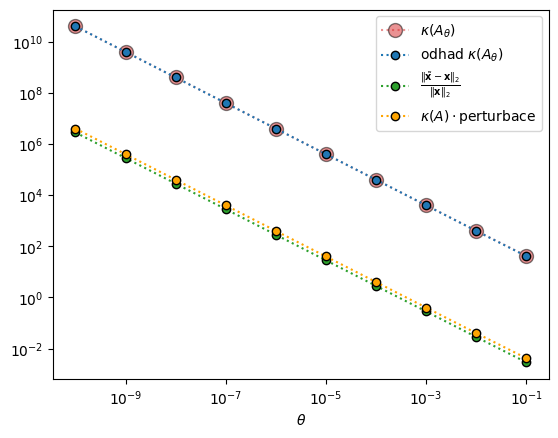

In [ ]:
def f(theta, rho=None, k=None, a=None, b=None ):
  """ Input 'theta' jsou body ve kterych vyhodnocujeme, zbyle inputy jsou optional, jen pro experimentaci s ruznymi typy 'f(x)'. """
  return theta**2

N = 50
theta = np.linspace(1,100,50); # theta = np.logspace(0,2,50);
f_theta = f(theta)

fig, [ax1,ax2,ax3] = plt.subplots(nrows=1, ncols=3, figsize=(13,5))
ax1.plot(theta,f(theta),'o:', color="tab:red", markeredgecolor="k"); ax1.set_xlabel(r"$\theta$"); ax1.set_ylabel(r"$f(\theta)$")
ax2.semilogy(theta,f(theta),'o:', color="tab:blue", markeredgecolor="k"); ax2.set_xlabel(r"$\theta$")
ax3.loglog(theta,f(theta),'o:', color="tab:green", markeredgecolor="k"); ax3.set_xlabel(r"$\theta$")
plt.show()

---
*Řešení*

- Pokud $\|\mathbf{e}_{k}\| = \rho \|\mathbf{e}_{k-1}\|$ pro libovolné $k>0$ pak $\|\mathbf{e}_{k}\| = \rho^k \|\mathbf{e}_{0}\|$ a tedy graf $\|\mathbf{e}_{k}\|$ v logaritmickém měřítku na ose $y$ odpovídá
$$ \log\left( \|\mathbf{e}_{k}\| \right) = \log\left( \rho^k \|\mathbf{e}_{0}\| \right) = k \log\left( \rho \right) + \log\left( \|\mathbf{e}_{0}\| \right) $$
a tedy grafem bude přímka - **lineární funkce** se sklonem $\rho$ a s hodnotou $\log\left( \|\mathbf{e}_{0}\| \right)$ pro $k=0$. Odtud plyne název lineární konvergence.

- Pro posloupnost konvergující superlineárně z definice platí, že konverguje *asymptoticky* rychleji než lineárně, tj. graf takové posloupnosti bude asymptoticky (tj. od určitého $k_0$ nadále) pod grafem libovolné lineární konvergence (tj. pod libovolnou přímkou). Konkrétně si můžeme vzít všechny  "tečny" grafu (tj. spojnice každé dvojice bodů $(k,\|\mathbf{e}_{k}\|)$ a $(k+1,\|\mathbf{e}_{k+1}\|)$) a graf superlineárně konvergující posloupnosti bude (asymptoticky) ohraničen zeshora tímto obalem z tečen. Funkce, jejichž graf leží pod jejich tečnou v každém bodě jsou ***konkávní*** a tedy graf graf superlineárně konvergující posloupnosti je (asymptoticky) konkávní.

- Pro posloupnost konvergující sublineárně z definice platí, že konverguje *asymptoticky* pomaleji než lineárně, tj. graf takové posloupnosti bude asymptoticky (tj. od určitého $k_0$ nadále) nad grafem libovolné lineární konvergence (tj. pod libovolnou přímkou). Analogicky usoudíme, že graf sublineárně konvergující posloupnosti je (asymptoticky) konvexní.

- Zjevně $\log(\theta_i^2) = 2 \log(\theta_i)$ a tedy pokud na ose $x$ vynášíme proměnou $\theta_i$ v logaritmickém měřítku (tj.$\log(\theta_i)$), pak graf hodnot $f(\theta_i)$ v logaritmickém měřítku na obou osách bude odpovídat přímce se sklonem 2 a s hodnotou $1$ v bodě $1$. Analogicky nahlédneme, že pro $f(\theta):= b \theta^{a}$ dostaneme $\log(b \theta^{a}) = a \log(\theta) + \log(b)$ a tedy pokud je v logaritmickém měřítku (na obou osách) grafem přímka, pak daná posloupnost/funkce odpovídá $f(\theta):= b \theta^{a}$ pro nějaké koeficienty $a,b$.
---

### Úloha A4: Aplikace

Systémy $(\star)$ si vezmeme ze zjednodušené, ale reálné aplikace - jeden problém odpovídá "[difuzi](https://en.wikipedia.org/wiki/Diffusion)" (česky "sálání") a druhý "[advekci](https://en.wikipedia.org/wiki/Advection)-difuzi" (česky "proudění-sálání"). Detaily jsou nastíněné v anotaci funkcí `get_ProblemDifuze(n)` a `get_ProblemAdvekceDifuze(n)`, které pro daný integer $n$ vrací matici a pravou stranu a tím definují systémy

$$
A_{diff} \mathbf{x}_{diff} =  \mathbf{b}_{diff}
\quad \mathrm{a} \quad
A_{advdiff} \mathbf{x}_{advdiff} =  \mathbf{b}_{adv diff}.
$$

Matice $A_{diff}$ je SPD a matice $A_{advdiff}$ je nenormální pro libovolné $n>2$. Po spuštění následujících dvou buněk s kódem se vykreslí vývoj chyby $\| \mathbf{e}_{k} \|_{1,2,\infty}$ jako funkce počtu iterací $k$ v *semi-logaritmickému měřítku v proměnné $y$* (tzn. přesně jako výše, viz [`plt.semilogy()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.semilogy.html)).

Na základě přednášky víme, že konvergenci stacionárních iteračních metod lze zaručit splněním

$$ \rho(I-M^{-1}A) < 1 \qquad \mathrm{nebo} \qquad \|| I-M^{-1}A \|| < 1 $$

pro libovolnou maticovou normu splňující $\|| X\mathbf{v} \|| \leq \|| X \|| \cdot \|| \mathbf{v} \||$.

Podmínka vpravo na normu iterační matice je vždy silnější než podmínka vlevo na spektrální poloměr iterační matice, ale v praxi často snáze ověřitelná (např. věta o konvergenci Jacobiho metody pro ostře diagonálně dominantní matice).



***Vlastnosti $A$ & $I-M^{-1}A$***

Pozor na přílišné zjednodušování - přestože $A_{diff}$ je SPD a tedy unitárně diagonalizovatelná, tak z toho neplyne, že $I-M^{-1}A_{diff}$ je také unitárně diagonalizovatelná (a analogicky pro $A_{advdiff}$).



***Charakterizace vlastních čísel skrze Rayleigho quotient***

Na cvičení k částečnému problému vlastních čísel si dokážeme následní charakterizaci největšíno a nejmenšího vlastního čísla pro obecnou symmetrickou & pozitivně definitní matici $A$. V Úloze B1 si dokážeme, že platí
  - $\lambda_{max} :=  \max\limits_{\lambda \, je \, vl. \, cislo \, A} \lambda = \max\limits_{\mathbf{x}\in \mathbb{R}^n, \, \mathbf{x}\neq 0} \tfrac{\mathbf{x}^TA\mathbf{x}}{\mathbf{x}^T\mathbf{x}}, \qquad (*)$
  - $\lambda_{min} :=  \min\limits_{\lambda \, je \, vl. \, cislo \, A} \lambda = \min\limits_{\mathbf{x}\in \mathbb{R}^n, \, \mathbf{x}\neq 0} \tfrac{\mathbf{x}^TA\mathbf{x}}{\mathbf{x}^T\mathbf{x}}. \qquad (**)$

---
**Tužka a Papír** : Detailně zdůvodněte průběh konvergence, kterou jsme vykreslili, za použití spočtených norem a spektrálních poloměrů.

**Tužka a Papír** : Při detailnějším čtení funkce `get_ProblemDifuze(n)` vidíme, že

$$ A_{diff} = (n+1)^2 \begin{bmatrix} 2 & -1 \\ -1 & \ddots & \ddots \\ & \ddots & \ddots & -1 \\ & & -1 & 2  \end{bmatrix} \in \mathbb{R}^{n\times n}. $$

Ukažte, že $A_{diff}$ je symetrická & pozitivně-definitní.

Pro Jacobiho metodu

- Vyjádřete iterační matici $T = I - M^{-1}$ pomocí $A_{diff}$.
- Ukažte, že $I-T$ a $I+T$ jsou pozitivně definitní.
- Ukažte, že $\rho(T) < 1$.
- Ukažte, že Jacobiho metoda konverguje monotóně.

- [Nápovědy & hinty](#hinty-a4)
---

---
***Řešení***

- Pro Jacobiho metodu máme $M=(n+1)^2 \cdot \mathrm{diag}(2,\dotsc ,2)$ a tedy
$$ T = I-M^{-1}A = I - \frac{1}{2} A_{diff} .$$

- Zjevně $I-T = \frac{1}{2} A_{diff}$ je symetrická & pozitivně definitní

- Zjevně $$I+T = \begin{bmatrix} 2 & 1 \\ 1 & \ddots & \ddots \\ & \ddots & \ddots & 1 \\ & & 1 & 2  \end{bmatrix}$$ je symetrická navíc $$\mathbf{x}^T(I+T )\mathbf{x} = \frac{1}{2} \mathbf{x}_1^2 + \frac{1}{2} \mathbf{x}^2_n + \sum\limits_{i=1}^{n} (\mathbf{x}_i + \mathbf{x}_{i+1})^2,$$ a tedy pozitivně definitní.

- Pokud je $I - T$ pozitivně defintní, pak jistě platí $\mathbf{x}^T\mathbf{x} > \mathbf{x}^TT\mathbf{x}$ a tedy $\lambda_{max}<1$. Analogicky z pozitivní definitnosti $I+T$ dostaneme $\lambda_{min}>1$ a z defnice tedy $\rho(T) < 1$ a Jacobiho metoda konverguje. Protože $T$ je symetrická, je i unitárně diagonalizovatelná a tedy konvergence je monotonní díky předchozí úloze.

---

In [ ]:
##################### Je nutne tuto bunku spustit, neni nutne (a asi ani vhodne) v ni cokoliv psat/menit
##################### Anotaci funkci si muzete precist (jinak bych se s tim nepsal), ale neni stezejni k pokracovani cvika
##################### Lze v klidu pokracovat s tim, ze mame preddefinovane 2 funkce, ktere nam kazda vraceji matici a pravou stranu, ktere "nejsou uplne vycucane z prstu"

def get_ProblemDifuze(n):
  '''
  Vrati nam matici "A" a vektor prave strany "b" t., ze reseni aproximuje "asymptoticke rozlozeni teploty vody v trubce" - pro zajemce, odpovida to nasledujicimu set-upu:
    - Predstavime si 1D trubku, ktere je plna vody a je na obou koncich uzavrena.
    - Na levy okraj trubky priplacneme ohrivak o teplote 100 °C.
    - Na pravy okraj trubky priplacneme led o teplote 0 °C.
    - Budeme predpokladat, ze mimo okraju trubka perfektne izoluje, tj. jedine tepelne zdroje jsou na okrajich. Take budeme predpokladat, ze nam led nikdy neroztaje.
    - Otazka, kterou si muzeme polozit : kdyz nechame trubku dostatecne dlouho v klidu, jak bude vypadat teplota vody v trubce?
    - Nejjednodussi zpusob aproximace vysledneho teplotniho profilu vody v trubce vede na problem Ax=b
  Proc ma "A" a "b" vypadat zrovna takhle se muzete dozvedet napr. v predmetu "NMMA338: Numerické řešení parciálních diferenciálních rovnic".
  '''
  h = 1/(n+1)
  A = 1/h**2 * ( 2*np.diag(np.ones(n),0) - np.diag(np.ones(n-1),-1) - np.diag(np.ones(n-1),1) )
  b = np.zeros(n); LeftDirichletBC = 100; b[0] = 1/h**2 * LeftDirichletBC
  return A, b

def get_ProblemAdvekceDifuze(n,adv_coeff=2.15):
  '''
  Vrati nam matici "A" a vektor prave strany "b" t., ze reseni aproximuje "asymptoticke rozlozeni teploty vody v trubce" - pro zajemce, odpovida to nasledujicimu set-upu:
    - Stejne jako vyse :
      - Predstavime si 1D trubku, ktere je plna vody a je na obou koncich uzavrena.
      - Na levy okraj trubky priplacneme ohrivak o teplote 100 °C.
      - Na pravy okraj trubky priplacneme led o teplote 0 °C.
      - Budeme predpokladat, ze mimo okraju trubka perfektne izoluje, tj. jedine tepelne zdroje jsou na okrajich. Take budeme predpokladat, ze nam led nikdy neroztaje.
    - Navic si situaci udelame zajimavejsi tim, ze
      - Vyvrtame v obou koncich trubky diru.
      - Levym okrajem nechame do trubky proudit vodu o teplote 100 °C (predehratou).
      - Pravym okrajem nechame z trubky vytekat vodu o teplote 0 °C (ochlazenou v dusledku ledu na zbytkupraveho okraje).
      - "Silu proudu" zleva doprava budeme kontrolovat koeficientem "adv_coeff" - mel by byt v intervalu [0,+nekonecno) - cim vyssi, tim silnejsi proud.
      - Zanedbame turbulence/viry vodniho toku uvnitr trubky.
    - Prirozena intuice je, ze
      - pokud "adv_coeff=0", pak dostaneme zpatky "ProblemDifuze".
      - pokud "adv_coeff>>0", pak nam silny proud nazene teplo z leveho okraje i dost blizko chlazeni na pravem okraji.

    - Otazka, kterou si muzeme polozit : kdyz nechame trubku dostatecne dlouho v klidu, jak bude vypadat teplota vody v trubce?
      - pokud "adv_coeff=0", pak ocekavame, ze se teplota rovnomerne rozprostre mezi 100 °C a 0 °C podel cele trubky.
      - pokud "adv_coeff>>0", pak ocekavame, ze se teplota bude blizko 100 °C i vyrazne dale od leveho konce, protoze ji tam proud neustale unasi a pravy konec ji "nestiha uchladit".
    - Nejjednodussi zpusob aproximace vysledneho teplotniho profilu vody v trubce vede na problem Ax=b
  Proc ma "A" a "b" vypadat zrovna takhle se muzete dozvedet napr. v predmetu "NMMA338: Úvod do parciálních diferenciálních rovnic".
  '''
  h = 1/(n+1); adv_coeff = adv_coeff/h # "adv_coeff ~ 1/DiscretePeclet"
  A = 1/h**2 * ( 2*np.diag(np.ones(n),0) - np.diag(np.ones(n-1),-1) - np.diag(np.ones(n-1),1) )  +  adv_coeff * 1/(2*h) * ( np.diag(np.ones(n-1),1) - np.diag(np.ones(n-1),-1) )
  b = np.zeros(n); LeftDirichletBC = 100; b[0] = 1/h**2 * LeftDirichletBC  + adv_coeff * 1/(2*h) * LeftDirichletBC
  return A, b


##################### Demo
n=100 #parametr urcujici "presnost aproximace". Cim vetsi, tim lepsi, ale pro n>>1000 to bude bezet netrivialne dlouho

### sestavime A, b pro problem "difuze"
A,b = get_ProblemDifuze(n); u_diff = np.linalg.solve(A,b); x = np.linspace(0,100,n+2); u_diffBC = np.concatenate( (np.array([100]), u_diff ,np.array([0])) )
### sestavime A, b pro problem "advekce-difuze"
adv_coeff = 1/10 # cislo z intervalu (0,+infty) -> pro "adv_coeff >> 2" ocekavame numerickou nestabilitu
A,b = get_ProblemAdvekceDifuze(n,adv_coeff); u_advdiff = np.linalg.solve(A,b); u_advdiffBC = np.concatenate( (np.array([100]), u_advdiff ,np.array([0])) )

fig, [ax1,ax2] = plt.subplots(nrows=1, ncols=2, sharex=True, sharey=False, figsize=(20,6))

ax1.plot(x, u_diffBC, '-', lw=2, c='tab:green')
ax1.yaxis.set_tick_params(labelsize=15); ax1.xaxis.set_tick_params(labelsize=15)
ax1.set_ylabel('teplota vody uvnitr trubky [°C]',fontsize=15); ax1.set_xlabel('vzdalenost od leveho okraje v trubce [cm]',fontsize=15); ax1.set_title(r"'Difuze': zadny pritok ani odtok", fontsize=20)
#ax1.set_ylim( 0.3*min( np.min(Chyby_AdvDiff_GS_Inf) , np.min(Chyby_AdvDiff_Jac_Inf) ), 3*max( np.max(Chyby_AdvDiff_GS_Inf) , np.max(Chyby_AdvDiff_Jac_Inf) ))

ax2.plot(x, u_advdiffBC, '-', lw=2, c='tab:green')
ax2.yaxis.set_tick_params(labelsize=15); ax2.xaxis.set_tick_params(labelsize=15)
ax2.set_ylabel('teplota vody uvnitr trubky [°C]',fontsize=15); ax2.set_xlabel('vzdalenost od leveho okraje v trubce [cm]',fontsize=15); ax2.set_title(r"'Advekce-difuze': diry s pritokem a odtokem", fontsize=20)
plt.show()

In [ ]:
######################################################################################################################################################
### vypocet Jacobi & Gauss-Seidel iteraci pro nase dva systemy - zacatek
pocetiter = 150 # pocet iteraci provedenych Jacobiho a Gauss-Seidelem
n = 100; initguess = np.random.rand(n);

### sestavime A, b pro problem "difuze"
A_diff,b_diff = get_ProblemDifuze(n); u_diff = np.linalg.solve(A_diff,b_diff);
#experimenty s Jacobiho metodou
Aproximace_Diff_Jac = JacobihoMetoda(A_diff, b_diff, initguess, pocetiter)
Chyby_Diff_Jac_1 = np.linalg.norm(Aproximace_Diff_Jac - u_diff, axis=1, ord=1) / np.linalg.norm(Aproximace_Diff_Jac[0,:] - u_diff, ord=1)
Chyby_Diff_Jac_2 = np.linalg.norm(Aproximace_Diff_Jac - u_diff, axis=1, ord=2) / np.linalg.norm(Aproximace_Diff_Jac[0,:] - u_diff, ord=2)
Chyby_Diff_Jac_Inf = np.linalg.norm(Aproximace_Diff_Jac - u_diff, axis=1, ord=np.inf)  / np.linalg.norm(Aproximace_Diff_Jac[0,:] - u_diff, ord=np.inf)
#experimenty s Gauss-Seidel metodou
Aproximace_Diff_GS = GaussSeidelMetoda(A_diff, b_diff, initguess, pocetiter)
Chyby_Diff_GS_1 = np.linalg.norm(Aproximace_Diff_GS - u_diff, axis=1, ord=1) / np.linalg.norm(Aproximace_Diff_GS[0,:] - u_diff, ord=1)
Chyby_Diff_GS_2 = np.linalg.norm(Aproximace_Diff_GS - u_diff, axis=1, ord=2) / np.linalg.norm(Aproximace_Diff_GS[0,:] - u_diff, ord=2)
Chyby_Diff_GS_Inf = np.linalg.norm(Aproximace_Diff_GS - u_diff, axis=1, ord=np.inf) / np.linalg.norm(Aproximace_Diff_GS[0,:] - u_diff, ord=np.inf)


### sestavime A, b pro problem "advekce-difuze"
A_advdiff,b_advdiff = get_ProblemAdvekceDifuze(n); u_advdiff = np.linalg.solve(A_advdiff,b_advdiff);
#experimenty s Jacobiho metodou
Aproximace_AdvDiff_Jac = JacobihoMetoda(A_advdiff, b_advdiff, initguess, pocetiter)
Chyby_AdvDiff_Jac_1 = np.linalg.norm(Aproximace_AdvDiff_Jac - u_advdiff, axis=1, ord=1) / np.linalg.norm(Aproximace_AdvDiff_Jac[0,:] - u_advdiff,ord=1)
Chyby_AdvDiff_Jac_2 = np.linalg.norm(Aproximace_AdvDiff_Jac - u_advdiff, axis=1, ord=2) / np.linalg.norm(Aproximace_AdvDiff_Jac[0,:] - u_advdiff, ord=2)
Chyby_AdvDiff_Jac_Inf = np.linalg.norm(Aproximace_AdvDiff_Jac - u_advdiff, axis=1, ord=np.inf) / np.linalg.norm(Aproximace_AdvDiff_Jac[0,:] - u_advdiff, ord=np.inf)
#experimenty s Gauss-Seidel metodou
Aproximace_AdvDiff_GS = GaussSeidelMetoda(A_advdiff, b_advdiff, initguess, pocetiter)
Chyby_AdvDiff_GS_1 = np.linalg.norm(Aproximace_AdvDiff_GS - u_advdiff, axis=1, ord=1) / np.linalg.norm(Aproximace_AdvDiff_GS[0,:] - u_advdiff, ord=1)
Chyby_AdvDiff_GS_2 = np.linalg.norm(Aproximace_AdvDiff_GS - u_advdiff, axis=1, ord=2) / np.linalg.norm(Aproximace_AdvDiff_GS[0,:] - u_advdiff, ord=2)
Chyby_AdvDiff_GS_Inf = np.linalg.norm(Aproximace_AdvDiff_GS - u_advdiff, axis=1, ord=np.inf) / np.linalg.norm(Aproximace_AdvDiff_GS[0,:] - u_advdiff, ord=np.inf)
### vypocet Jacobi & Gauss-Seidel iteraci pro nase dva systemy - konec
######################################################################################################################################################






######################################################################################################################################################
### predikce konvergence Jacobi & Gauss-Seidel iteraci - zacatek
ChciPracovatsNormamaAPolomerama = True

if ChciPracovatsNormamaAPolomerama:

  ### vypocty pro problem "difuze" - pracujeme s matici A = A_diff
  A = A_diff
  # Jacobiho metoda
  M = np.diag(np.diag(A)); N = M - A; IteracniMatice_Diff_Jac = np.linalg.solve(M,N);
  SpektrPolomer_Diff_Jac = np.max( np.abs(np.linalg.eigvals( IteracniMatice_Diff_Jac )) )
  Norma1_Diff_Jac = np.linalg.norm(IteracniMatice_Diff_Jac, ord=1)
  Norma2_Diff_Jac = np.linalg.norm(IteracniMatice_Diff_Jac, ord=2)
  NormaInf_Diff_Jac = np.linalg.norm(IteracniMatice_Diff_Jac, ord=np.inf)
  # Gauss-Seidel metoda
  M = np.tril(A); N = M - A; IteracniMatice_Diff_GS = np.linalg.solve(M,N);
  SpektrPolomer_Diff_GS = np.max( np.abs(np.linalg.eigvals( IteracniMatice_Diff_GS )) )
  Norma1_Diff_GS = np.linalg.norm(IteracniMatice_Diff_GS, ord=1)
  Norma2_Diff_GS = np.linalg.norm(IteracniMatice_Diff_GS, ord=2)
  NormaInf_Diff_GS = np.linalg.norm(IteracniMatice_Diff_GS, ord=np.inf)


  ### vypocty pro problem "advekce-difuze" - pracujeme s matici A = A_advdiff
  A = A_advdiff
  # Jacobiho metoda
  M = np.diag(np.diag(A)); N = M - A; IteracniMatice_AdvDiff_Jac = np.linalg.solve(M,N);
  SpektrPolomer_AdvDiff_Jac = np.max( np.abs(np.linalg.eigvals( IteracniMatice_AdvDiff_Jac )) )
  Norma1_AdvDiff_Jac = np.linalg.norm(IteracniMatice_AdvDiff_Jac, ord=1)
  Norma2_AdvDiff_Jac = np.linalg.norm(IteracniMatice_AdvDiff_Jac, ord=2)
  NormaInf_AdvDiff_Jac = np.linalg.norm(IteracniMatice_AdvDiff_Jac, ord=np.inf)
  # Gauss-Seidel metoda
  M = np.tril(A); N = M - A; IteracniMatice_AdvDiff_GS = np.linalg.solve(M,N);
  SpektrPolomer_AdvDiff_GS = np.max( np.abs(np.linalg.eigvals( IteracniMatice_AdvDiff_GS )) )
  Norma1_AdvDiff_GS = np.linalg.norm(IteracniMatice_AdvDiff_GS, ord=1)
  Norma2_AdvDiff_GS = np.linalg.norm(IteracniMatice_AdvDiff_GS, ord=2)
  NormaInf_AdvDiff_GS = np.linalg.norm(IteracniMatice_AdvDiff_GS, ord=np.inf)
### predikce konvergence Jacobi & Gauss-Seidel iteraci - konec
######################################################################################################################################################



######################################################################################################################################################
### vykreslovani zacatek
fig, [[ax1,ax2,ax3],[ax4,ax5,ax6]] = plt.subplots(nrows=2, ncols=3, sharex=True, sharey=False, figsize=(22,9))
iterace = np.arange(0,pocetiter+1,1, dtype=np.float64)

ax1.semilogy(Chyby_Diff_Jac_1, 'o', lw=0, markerfacecolor='tab:red', markeredgecolor='k', ms=12)
ax1.semilogy(Chyby_Diff_GS_1, 's', lw=0, markerfacecolor='tab:blue', markeredgecolor='k', ms=12)
ax1.yaxis.set_tick_params(labelsize=15); ax1.xaxis.set_tick_params(labelsize=15); ax1.set_title(r"Pouzita norma: $\| \cdot \|_{1}$", fontsize=20)
ax1.set_ylim( 0.95*min( np.min(Chyby_Diff_GS_1) , np.min(Chyby_Diff_Jac_1) ), 1.05*max( np.max(Chyby_Diff_GS_1) , np.max(Chyby_Diff_Jac_1) ))
ax1.set_ylabel(r"normalni matice (diff)", fontsize=20)
if ChciPracovatsNormamaAPolomerama:
  ax1.semilogy(SpektrPolomer_Diff_GS**iterace, ':', color='tab:blue', lw=4)
  ax1.semilogy(SpektrPolomer_Diff_Jac**iterace, ':', color='tab:red', lw=4)
  all_handles = []; all_labels = []; line1, = ax1.plot([10,11],[0.9,0.8], '-', lw=0, color='white');
  all_handles.extend([line1,line1]); all_labels.extend([r'Jacobi: $\|I-M^{-1}A\|_{1} \approx $' + '{:.2e}'.format(Norma1_Diff_Jac), r'Gauss-Seidel: $\|I-M^{-1}A\|_{1} \approx $' + '{:.2e}'.format(Norma1_Diff_GS)])
  ax1.legend(all_handles, all_labels, loc='lower left', fancybox=True, shadow=True, ncol=1, fontsize=15)

ax2.semilogy(Chyby_Diff_Jac_2, 'o', lw=0, markerfacecolor='tab:red', markeredgecolor='k', ms=12)
ax2.semilogy(Chyby_Diff_GS_2, 's', lw=0, markerfacecolor='tab:blue', markeredgecolor='k', ms=12)
ax2.yaxis.set_tick_params(labelsize=15); ax2.xaxis.set_tick_params(labelsize=15); ax2.set_title(r"Pouzita norma: $\| \cdot \|_{2}$", fontsize=20)
ax2.set_ylim( 0.95*min( np.min(Chyby_Diff_GS_2) , np.min(Chyby_Diff_Jac_2) ), 1.05*max( np.max(Chyby_Diff_GS_2) , np.max(Chyby_Diff_Jac_2) ))
if ChciPracovatsNormamaAPolomerama:
  ax2.semilogy(SpektrPolomer_Diff_GS**iterace, ':', color='tab:blue', lw=4)
  ax2.semilogy(SpektrPolomer_Diff_Jac**iterace, ':', color='tab:red', lw=4)
  all_handles = []; all_labels = []; line1, = ax2.plot([10,11],[0.9,0.8], '-', lw=0, color='white');
  all_handles.extend([line1,line1]); all_labels.extend([r'Jacobi: $\|I-M^{-1}A\|_{2} \approx $' + '{:.2e}'.format(Norma2_Diff_Jac), r'Gauss-Seidel: $\|I-M^{-1}A\|_{2} \approx $' + '{:.2e}'.format(Norma2_Diff_GS)])
  ax2.legend(all_handles, all_labels, loc='lower left', fancybox=True, shadow=True, ncol=1, fontsize=15)

ax3.semilogy(Chyby_Diff_Jac_Inf, 'o', lw=0, markerfacecolor='tab:red', markeredgecolor='k', ms=12)
ax3.semilogy(Chyby_Diff_GS_Inf, 's', lw=0, markerfacecolor='tab:blue', markeredgecolor='k', ms=12)
ax3.yaxis.set_tick_params(labelsize=15); ax3.xaxis.set_tick_params(labelsize=15); ax3.set_title(r"Pouzita norma: $\| \cdot \|_{\infty}$", fontsize=20)
ax3.set_ylim( 0.95*min( np.min(Chyby_Diff_GS_Inf) , np.min(Chyby_Diff_Jac_Inf) ), 1.05*max( np.max(Chyby_Diff_GS_Inf) , np.max(Chyby_Diff_Jac_Inf) ))
if ChciPracovatsNormamaAPolomerama:
  ax3.semilogy(SpektrPolomer_Diff_GS**iterace, ':', color='tab:blue', lw=4)
  ax3.semilogy(SpektrPolomer_Diff_Jac**iterace, ':', color='tab:red', lw=4)
  all_handles = []; all_labels = []; line1, = ax3.plot([10,11],[0.9,0.8], '-', lw=0, color='white');
  all_handles.extend([line1,line1]); all_labels.extend([r'Jacobi: $\|I-M^{-1}A\|_{\infty} \approx $' + '{:.2e}'.format(NormaInf_Diff_Jac), r'Gauss-Seidel: $\|I-M^{-1}A\|_{\infty} \approx $' + '{:.2e}'.format(NormaInf_Diff_GS)])
  ax3.legend(all_handles, all_labels, loc='lower left', fancybox=True, shadow=True, ncol=1, fontsize=15)


ax4.semilogy(Chyby_AdvDiff_Jac_1, 'o', lw=0, markerfacecolor='tab:red', markeredgecolor='k', ms=12)
ax4.semilogy(Chyby_AdvDiff_GS_1, 's', lw=0, markerfacecolor='tab:blue', markeredgecolor='k', ms=12)
ax4.yaxis.set_tick_params(labelsize=15); ax4.xaxis.set_tick_params(labelsize=15)
ax4.set_ylim( 0.3*min( np.min(Chyby_AdvDiff_GS_1) , np.min(Chyby_AdvDiff_Jac_1) ), 3*max( np.max(Chyby_AdvDiff_GS_1) , np.max(Chyby_AdvDiff_Jac_1) ))
ax4.set_ylabel(r"ne-normalni matice (adv-diff)", fontsize=20)
if ChciPracovatsNormamaAPolomerama:
  ax4.semilogy(SpektrPolomer_AdvDiff_Jac**iterace, ':', color='tab:red', lw=4)
  ax4.semilogy(SpektrPolomer_AdvDiff_GS**iterace, ':', color='tab:blue', lw=4)
  all_handles = []; all_labels = []; line1, = ax4.plot([10,11],[0.9,0.8], '-', lw=0, color='white');
  all_handles.extend([line1,line1]); all_labels.extend([r'Jacobi: $\|I-M^{-1}A\|_{1} \approx $' + '{:.2e}'.format(Norma1_AdvDiff_Jac), r'Gauss-Seidel: $\|I-M^{-1}A\|_{1} \approx $' + '{:.2e}'.format(Norma1_AdvDiff_GS)])
  ax4.legend(all_handles, all_labels, loc='lower right', fancybox=True, shadow=True, ncol=1, fontsize=15)

ax5.semilogy(Chyby_AdvDiff_Jac_2, 'o', lw=0, markerfacecolor='tab:red', markeredgecolor='k', ms=12)
ax5.semilogy(Chyby_AdvDiff_GS_2, 's', lw=0, markerfacecolor='tab:blue', markeredgecolor='k', ms=12)
ax5.yaxis.set_tick_params(labelsize=15); ax5.xaxis.set_tick_params(labelsize=15)
ax5.set_ylim( 0.3*min( np.min(Chyby_AdvDiff_GS_2) , np.min(Chyby_AdvDiff_Jac_2) ), 3*max( np.max(Chyby_AdvDiff_GS_2) , np.max(Chyby_AdvDiff_Jac_2) ))
if ChciPracovatsNormamaAPolomerama:
  ax5.semilogy(SpektrPolomer_AdvDiff_GS**iterace, ':', color='tab:blue', lw=4)
  ax5.semilogy(SpektrPolomer_AdvDiff_Jac**iterace, ':', color='tab:red', lw=4)
  all_handles = []; all_labels = []; line1, = ax5.plot([10,11],[0.9,0.8], '-', lw=0, color='white');
  all_handles.extend([line1,line1]); all_labels.extend([r'Jacobi: $\|I-M^{-1}A\|_{2} \approx $' + '{:.2e}'.format(Norma2_AdvDiff_Jac), r'Gauss-Seidel: $\|I-M^{-1}A\|_{2} \approx $' + '{:.2e}'.format(Norma2_AdvDiff_GS)])
  ax5.legend(all_handles, all_labels, loc='lower right', fancybox=True, shadow=True, ncol=1, fontsize=15)

ax6.semilogy(Chyby_AdvDiff_Jac_Inf, 'o', lw=0, markerfacecolor='tab:red', markeredgecolor='k', ms=12)
ax6.semilogy(Chyby_AdvDiff_GS_Inf, 's', lw=0, markerfacecolor='tab:blue', markeredgecolor='k', ms=12)
ax6.yaxis.set_tick_params(labelsize=15); ax6.xaxis.set_tick_params(labelsize=15)
ax6.set_ylim( 0.3*min( np.min(Chyby_AdvDiff_GS_Inf) , np.min(Chyby_AdvDiff_Jac_Inf) ), 3*max( np.max(Chyby_AdvDiff_GS_Inf) , np.max(Chyby_AdvDiff_Jac_Inf) ))
if ChciPracovatsNormamaAPolomerama:
  ax6.semilogy(SpektrPolomer_AdvDiff_GS**iterace, ':', color='tab:blue', lw=4)
  ax6.semilogy(SpektrPolomer_AdvDiff_Jac**iterace, ':', color='tab:red', lw=4)
  all_handles = []; all_labels = []; line1, = ax6.plot([10,11],[0.9,0.8], '-', lw=0, color='white');
  all_handles.extend([line1,line1]); all_labels.extend([r'Jacobi: $\|I-M^{-1}A\|_{\infty} \approx $' + '{:.2e}'.format(NormaInf_AdvDiff_Jac), r'Gauss-Seidel: $\|I-M^{-1}A\|_{\infty} \approx $' + '{:.2e}'.format(NormaInf_AdvDiff_GS)])
  ax6.legend(all_handles, all_labels, loc='lower right', fancybox=True, shadow=True, ncol=1, fontsize=15)


if ChciPracovatsNormamaAPolomerama:
  ax = plt.gca(); fig = plt.gcf(); all_handles = []; all_labels = []
  line1, = ax.plot([1,1],[1,1], '-o', lw=0, markerfacecolor='tab:red', markeredgecolor='k', ms=12); line2, = ax.plot([1,1],[1,1], '-s', lw=0, markerfacecolor='tab:blue', markeredgecolor='k', ms=12)
  line3, = ax.plot([100,101],[1e-5,1e-7], ':', lw=5, color='tab:gray'); line3b, = ax.plot([100,101],[1e-5,1e-7], '-', lw=10, color='white')
  all_handles.extend([line1, line2, line3])
  all_labels.extend([r'Jacobi', r'Gauss-Seidel', r'sklon $\rho(I - M^{-1}A)^k$'])
  fig.legend(all_handles, all_labels, loc='upper center', bbox_to_anchor=(0.5, 0.05), fancybox=True, shadow=True, ncol=3, fontsize=30)
  plt.tight_layout(rect=[0, 0.05, 1, 1])
else:
  ax = plt.gca(); fig = plt.gcf(); all_handles = []; all_labels = []
  line1, = ax.plot([1,1],[1,1], '-o', lw=0, markerfacecolor='tab:red', markeredgecolor='k', ms=12); line2, = ax.plot([1,1],[1,1], '-s', lw=0, markerfacecolor='tab:blue', markeredgecolor='k', ms=12)
  line3, = ax.plot([100,101],[1e-5,1e-7], ':', lw=5, color='tab:gray'); line3b, = ax.plot([100,101],[1e-5,1e-7], '-', lw=10, color='white')
  all_handles.extend([line1, line2])
  all_labels.extend([r'Jacobi', r'Gauss-Seidel'])
  fig.legend(all_handles, all_labels, loc='upper center', bbox_to_anchor=(0.5, 0.05), fancybox=True, shadow=True, ncol=3, fontsize=30)
  plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.show()
### vykreslovani konec
######################################################################################################################################################

## Část B: Stacionární metody & polynomy

Stacionární matody byly populární druhé polovině minulého století, ale jejich popularita začala ustupovat ve prospěch tzv. [metod Krylovovských prostorů](https://en.wikipedia.org/wiki/Krylov_subspace#Existing_methods) - o Krylovovské prostory ještě potkáme v rámci problému vlastních čísel.

My se podíváme právě na přechod od stacionárních metod ke Krylovovským pro nejjednoduší stacionární metodu - [Richardsonovu metodu](https://en.wikipedia.org/wiki/Modified_Richardson_iteration), která odpovídá volbě $M=I$, $N = I-A$ a je tedy definována iterací
$$ \mathbf{x}_{k} = (I-A)\mathbf{x}_{k-1} +\mathbf{b} = \mathbf{x}_{k-1} + (\mathbf{b} - A\mathbf{x}_{k-1}).$$

Zároveň připomeneme, že pro matice umíme definovat *polynomy matic* pro libovlnou čtvercovou matici - například pro $X\in \mathbb{R}^{n\times n}$ a pro polynom $p(t) := t^2-4t+3 = (t-3)(t-1)$ platí
$$ p(X) = X^2-4X+2I_n = (X-3I_n)(X-I_n). $$

### Úloha B1 - Richardsonova metoda & Krylov

---
**Tužka a papír**:

  - na základě rekurence pro aproximace $\mathbf{x}_k$ Richardsonovy metody odvoďte rekurenci pro *rezidua* Richardsonovy metody.

- pomocí této rekurence najděte reálný polynom $q_2(t)$, pro který platí $\mathbf{r}_2 = q_2(I-A) \mathbf{r}_0$. Následně zobecněte pro $k$-té reziduum a najděte příslušný $q_k(t)$ stupně nejvýše $k$.
  
- najděte reálný polynom $p_k(t)$ stupně nejvýše $k$, pro který platí $\mathbf{r}_k = p_k(A) \mathbf{r}_0$.

- Ukažte

$$\left\{ f_k(A) \mathbf{v}_0 \, | \, f_k(t) \; \mathrm{je \; polynom} \; \& \; \mathrm{deg}(f_k) \leq  k-1 \; \& \; f_k(0)=1 \right\}  = \mathbf{v}_0 + A \cdot \mathrm{span} \left( \mathbf{v}_0, A\mathbf{v}_0, \dotsc , A^{k-1}\mathbf{v}_0  \right)$$

- [Nápověda & hinty](#hinty-b1)

----

Jinými slovy, Richardsonova metoda konstruuje aproximace $\mathbf{x}_k$ tak, že rezidua $\mathbf{r}_k$ leží v prostoru

$$ \mathbf{r}_0 + A \cdot \underbrace{ \, \mathrm{span} \left( \mathbf{r}_0, A\mathbf{r}_0, \dotsc , A^{k-1}\mathbf{r}_0  \right) \, }_{=: \, \mathcal{K}_{k}(A,\mathbf{r}_0)} \, \equiv \,  \mathbf{r}_0 + A \cdot \mathcal{K}_{k}(A,\mathbf{r}_0) ,$$

který je definován pomocí $\mathcal{K}_{k}(A,\mathbf{r}_0) $, tzv. [$k$-tého Krylovova podprostoru příslušejícího $A$ a $\mathbf{r}_0$](https://en.wikipedia.org/wiki/Krylov_subspace).


Iterační metody, které jsou dnes asi nejvíce používané fungují jako "vylepšováky" tohoto postupu. Volí $\mathbf{x}_k$ tak, aby stále platilo

$$\mathbf{r}_k \in  \mathbf{r}_0 + A \cdot \mathcal{K}_{k}(A,\mathbf{r}_0),$$

protože se dá ukázat, že to je z výpočetního hlediska vhodné/přirozené, ale snaží se "v jistém smyslu optimalizovat aproximaci $\mathbf{x}_k$" - například minimalizovat $\|\mathbf{r}_k\|$. Jinými slovy, nevolí vždy "stejný polynom $p_k(t)$", ale adaptují ho v každé iteraci na základě předešlých iterací. Těmto metodám se říká metody Krylovovských prostorů a vícew se o nich dozvíte během 3. ročníku, například v rámci předmětu [NMNM331: Analýza maticových výpočtů 1](https://is.cuni.cz/studium/predmety/index.php?do=predmet&kod=NMNM331).


---
***Řešení*** :

- vztah $ \mathbf{x}_{k} = \mathbf{x}_{k-1} + (\mathbf{b} - A\mathbf{x}_{k-1}) $ přenásobíme maticí $A$ a následně ho odečteme od $\mathbf{b}$ a dostaneme
$$ \mathbf{b} - A \mathbf{x}_{k} =  \mathbf{b} - A\mathbf{x}_{k-1} - A (\mathbf{b} - A\mathbf{x}_{k-1}) \quad \mathrm{nebo-li} \quad \mathbf{r}_{k} = ( I - A ) \mathbf{r}_{k-1},$$

- zjevně $q_k(t) = t^k$ a $p_k(t) = (1-t)^k$.

- stačí rozepsání $p_k(A) \mathbf{r}_0 = \left( 1 + \sum\limits_{i=1}^{k} \alpha_i A^i \right) \mathbf{r}_0 = \mathbf{r}_0 + A\sum\limits_{i=0}^{k} \alpha_i A^i \mathbf{r}_0  \in \mathbf{r}_0 + A \cdot \mathcal{K}_{k}(A,\mathbf{r}_0)$

---

### ZÚ - Krylov pro obecné štěpení

---
**Tužka a papír**:

  - na základě rekurence pro chybu $\mathbf{e}_k = \mathbf{x} - \mathbf{x}_k$ obecné stacionární metody založené na štěpení $A=M-N$ (máme ji na začátku worksheetu) odvoďte rekurenci pro *rezidua*.

  - analogicky k postupu v Úloze B1 vyjádřete $k$-té reziduum $\mathbf{r}_k$ jako nějaký reálný polynom $p_k(t)$ stupně nejvýše $k$ a splňující $p_k(0)=1$ v nějaké matici $X$ aplikovaný na počáteční reziduum, tj. najděte polynom $p_k(t)$ (stupně nejvýše $k$) a matici $X$ takové, že platí $\mathbf{r}_k = p_k(X) \mathbf{r}_0$ a zároveň $p_k(0)=1$.

  - s jakým Krylovovským podprostorem takto implicitně pracujeme?

----

***Řešení*** :

- vztah $\mathbf{e}_{k} = (I - M^{-1}A) \mathbf{e}_{k-1}$ nám dává

  $$ \mathbf{r}_{k} = A\mathbf{e}_{k} = A(I - M^{-1}A) \mathbf{e}_{k-1} = (I - AM^{-1}) A\mathbf{e}_{k-1} = (I - AM^{-1}) \mathbf{r}_{k-1} $$

  a tedy $\mathbf{r}_{k} = p_k(AM^{-1}) \mathbf{r}_{0}$ pro $p_k(t) = (1-t)^k$.


- stačí rozepsání $p_k(AM^{-1}) \mathbf{r}_0 = \left( 1 + \sum\limits_{i=1}^{k} \alpha_i (AM^{-1})^i \right) \mathbf{r}_0 = \mathbf{r}_0 + (AM^{-1})\sum\limits_{i=0}^{k} \alpha_i (AM^{-1})^i \mathbf{r}_0  \in \mathbf{r}_0 + AM^{-1} \cdot \mathcal{K}_{k}(AM^{-1},\mathbf{r}_0)$

## Hinty

### Hinty A1

#### Hint "užitečné funkce"

Budou se vám hodit funkce <a href="https://numpy.org/doc/2.3/reference/generated/numpy.diag.html">np.diag()</a> a <a href="https://numpy.org/doc/stable/reference/generated/numpy.tril.html">np.tril()</a> a také <a href="https://numpy.org/doc/stable/reference/generated/numpy.triu.html">np.triu()</a>.

#### Hint "neužitečné funkce"

Bude se vám hodit funkce <a href="https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html">np.linalg.solve()</a> - naopak se *vyvarujte* funkce <a href="https://numpy.org/doc/stable/reference/generated/numpy.linalg.inv.html">np.linalg.inv()</a>

#### Hint "kostra kódu"

  Kostra Vašeho kódu by mohla vypadat přibližně takto:

  ```
  # Inicializaci pole do ktereho si budeme ukladat aproximace x0, x1, ...
  MojeAproximace = np.zeros(( ... , ... ))
  MojeAproximace[0,:] = ...

  # Volba konkretniho stepeni
  M = ...
  N = ...
  
  # Provedeni potrebneho kroku metody
  for k in range(nmb_iter):
    MojeAproximace[k+1,:] = ...
  ```

### Hinty A2

#### Hint "unitární" 1

Využijte vlastnosti unitárních matic, tj. $\|U\mathbf{x}\| = \|\mathbf{x}\|$.

#### Hint "unitární" 2

Pokud máme reálnou diagonální matici $D$ a označíme její největší prvek v absolutní hodnotě $d_{\mathrm{max}}$, pak platí 

$$ \frac{|| D^{k+1} ||}{|| D^{k} ||} = \frac{|d_{\mathrm{max}}|^{k+1}}{|d_{\mathrm{max}}|^k} \frac{|| \left( \tfrac{1}{d_{\mathrm{max}}} D \right)^{k+1} ||}{|| \left( \tfrac{1}{d_{\mathrm{max}}} D \right)^{k} ||}.$$

#### Hint "diagonalizovatelná" 1

Vezměme si diagonalizovatelnou matici $X$, která není unitárně diagonalizovatelná. Co umíme (jestli vůbec něco) říct o souvislosti

$$ || X ||_2 := \max\limits_{||\mathbf{v}||=1} ||X\mathbf{v}|| \qquad \mathrm{a} \qquad \rho(X) := \max\limits_{\lambda \, \mathrm{je\, vl.\, c. \,} X} |\lambda |, $$
      
pro unitárně diagonalizovatelné matice a co pro ne-unitárně diagonalizovatelné?

#### Hint "diagonalizovatelná" 2

Pro důkaz lze použít stejnou myšlenku jako pro unitárně diagonalizovatelnou iterační matici, ale technika se musí přizpůsobit tomu, ře přechod do vlastní báze už může měnit normu. Navrhněte horní a spodní odhad

$$ c_{min} \leq \| S D^k S^{-1} \mathbf{e}_0 \| \leq C_{max}, $$

který respektuje ideu důkazu konvergence (viz Hint 2 pro unitárně diagonalizovatelné).

#### Hint "diagonalizovatelná" 3

Pro odhady z předchozího hintu se stačí trojúhelníková nerovnost.

### Hinty A3

#### Hint "vlastnosti grafů sup- & sub-lineární konvergence"

Ukažte, že semilogaritmický graf chyby (konvergující superlineárně k $0$) od určitého $k_0$ leží pod spojnicemi bodů $(k,\log_{10}(\|e_{k}\|)$ a $(k+1,\log_{10}(\|e_{k+1}\|)$. Analogická myšlenka by měla fungovat i pro sublineární konvergenci. Vzpomeňte si na definici konvexních/konkávních funkcí.

### Hinty A4

#### Hint "pozitivně definitní"

Pozitivní definitnost ukažte z definice, tj. $\mathbf{x}^TL\mathbf{x} > 0$ pro libovolné $\mathbf{x} \neq \mathbf{0}$.

#### Hint "spektrální poloměr" 1

Zjevně $\rho(T) = \max \{ \lambda_{min} ,\lambda_{max} \}$. Využijte charakterizace $(*)$ a $(**)$.

#### Hint "spektrální poloměr" 2

Pokud je $I-T$ pozitivně defintní, pak jistě platí $\mathbf{x}^T\mathbf{x} - \mathbf{x}^TT\mathbf{x} > 0$.

### Hinty B1

#### Hint "jak začít?"


Pro aproximaci $\mathbf{x}_k$ řešení systému $A\mathbf{x} = \mathbf{b}$ je reziduum definováno jako $A(\mathbf{x}-\mathbf{x}_k) = \mathbf{b} - A\mathbf{x}_k$, kde $\mathbf{x}$ je přesné řešení.

#### Hint "polynomy"

Ukažte, že libovolný polynom $p_k$ stupně nejvýše $k$, pro který platí $p_k(0)=1$, lze zapsat jako $p_k(t)=1 + t\cdot \tilde{p}_{k-1}(t)$ pro nějaký polynom $\tilde{p}_{k-1}(t)$ stupně nejvýše $k-1$.